# CNN Classifier with CycleGAN Synthetic Augmentation — Pneumonia vs Healthy

Train `SimpleCNN` using CycleGAN-generated synthetic pneumonia images as the augmentation strategy.

**Training set:**
- All healthy images from the training split (label = 0)
- Original pneumonia images from the training split (label = 1)
- Synthetic pneumonia images from CycleGAN **that flipped** according to CheXNet (label = 1)

Flip filtering is based on `results/cyclegan_h2p_train_scores.csv` produced by **notebook 2.1**.
Only synthetic images where CheXNet agrees they look like pneumonia are included.

**No geometric augmentation** — the CycleGAN synthesis is the augmentation.

**Val/Test sets:** unchanged from `val_dataset.pt` / `test_dataset.pt` (no recomputation).

Uses `pos_weight` on `BCEWithLogitsLoss` to handle class imbalance.  
**Reported metrics:** Accuracy and AUC-ROC on test dataset.

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from PIL import Image

from classifier import SimpleCNN
from dataset import PyTorchDataset
from device import DEVICE
from metrics import print_metrics, plot_roc_curve
from train_models import run_epoch, train_model, training_curves, save_results
import matplotlib.pyplot as plt

print(f"Device: {DEVICE}")

Device: cuda


## 2. Hyperparameters

In [2]:
from config import load_config

cfg = load_config(project_root / "configs" / "cyclegan_augmented_cnn.yaml", project_root)

print(f"Model:              {cfg.model.name}")
print(f"Dropout:            {cfg.model.dropout}")
print(f"Class balancing:    {cfg.data.class_balancing}")
print(f"Batch size:         {cfg.training.batch_size}")
print(f"LR:                 {cfg.training.lr}")
print(f"Epochs:             {cfg.training.num_epochs}")
print(f"Weight decay:       {cfg.training.weight_decay}")
print(f"Early stopping:     {cfg.training.early_stopping_patience}")
print(f"Seed:               {cfg.seed}")
print(f"Generated dir:      {cfg.data.generated_dir}")
print(f"Checkpoint:         {cfg.checkpoint_path}")
print(f"Results dir:        {cfg.results_dir}")

Model:              SimpleCNN_cyclegan_aug
Dropout:            0.3
Class balancing:    pos_weight
Batch size:         64
LR:                 0.0003
Epochs:             10
Weight decay:       0.0001
Early stopping:     5
Seed:               42
Generated dir:      data/generated/healthy_to_pneumonia
Checkpoint:         C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\models\cyclegan_augmented_cnn_20260615-232507.pt
Results dir:        C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\cyclegan_augmented_cnn_20260615-232507


In [3]:
BATCH_SIZE  = cfg.training.batch_size
LR          = cfg.training.lr
NUM_EPOCHS  = cfg.training.num_epochs
DROPOUT     = cfg.model.dropout
SEED        = cfg.seed

CHECKPOINT_PATH = cfg.checkpoint_path
RESULTS_DIR     = cfg.results_dir
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Base Dataset (from cache)

Val and test sets are loaded unchanged from the cached `.pt` files.  
The training `.pt` is used as the base; synthetic images are added on top without re-saving.

In [4]:
DATA_CACHE_DIR = project_root / "data" / "processed"

train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt",   weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt",  weights_only=False)

print(f"Base train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

base_labels = train_dataset.labels[:, 1]
n_base_pos  = int(base_labels.sum().item())
n_base_neg  = len(base_labels) - n_base_pos
print(f"Base train — Healthy: {n_base_neg} | Real pneumonia: {n_base_pos}")

Base train: 42661 | Val: 8993 | Test: 9021
Base train — Healthy: 42436 | Real pneumonia: 225


## 4. Load Synthetic Pneumonia Images (CycleGAN — flipped only)

Images are loaded **lazily** (paths only; read from disk in `__getitem__`).

Two filters are applied:
1. **Training-split only** — excludes images whose source healthy image belongs to val/test (prevents leakage).
2. **Flipped only** — keeps only synthetic images where CheXNet changed its prediction from healthy to pneumonia, as scored in notebook 2.1 (`results/cyclegan_h2p_train_scores.csv`).

**Run notebook 2.1 first** to generate the scores CSV.

In [5]:
class GeneratedPneumoniaDataset(Dataset):
    """Lazy-loading dataset for CycleGAN-generated synthetic pneumonia images.

    Reads images from disk on demand. All samples carry label [0, 1] (pneumonia).
    No transforms are applied — the CycleGAN synthesis is the augmentation.
    """

    def __init__(self, img_paths, metadata_list):
        self.img_paths = [Path(p) for p in img_paths]
        self.metadata  = torch.tensor(metadata_list, dtype=torch.float32)
        self.labels    = torch.zeros(len(img_paths), 2, dtype=torch.float32)
        self.labels[:, 1] = 1.0  # all are pneumonia

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("L")
        img_array  = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).unsqueeze(0)  # (1, H, W)
        return img_tensor, self.labels[idx], self.metadata[idx]

In [6]:
DATA_DIR = project_root / "data"
GEN_DIR  = project_root / cfg.data.generated_dir

# Build lookup: healthy training image name → metadata row
train_df      = pd.read_csv(DATA_DIR / "train_split.csv")
healthy_train = train_df[train_df["Label"] == 0].set_index("Image Index")
healthy_train_names = set(healthy_train.index)

# Load flip scores from notebook 2.1 — only keep images that CheXNet flipped
FLIP_CSV = project_root / "results" / "cyclegan_h2p_train_scores.csv"
flip_df  = pd.read_csv(FLIP_CSV)
flipped_names = set(flip_df.loc[flip_df["flip"] == 1, "image"])

print(f"Healthy images in training split:   {len(healthy_train_names)}")
print(f"Generated images in folder:         {len(list(GEN_DIR.glob('*.png')))}")
print(f"Images that flipped (CheXNet):      {len(flipped_names)}")

gen_img_paths = []
gen_metadata  = []

for img_path in sorted(GEN_DIR.glob("*.png")):
    name = img_path.name
    if name not in healthy_train_names:
        continue  # not from training split
    if name not in flipped_names:
        continue  # CheXNet did not flip — skip
    row = healthy_train.loc[name]
    gen_img_paths.append(img_path)
    gen_metadata.append([row["Patient Age Normalized"], row["Patient Gender Encoded"]])

print(f"Synthetic images after filtering:   {len(gen_img_paths)}")

Healthy images in training split:   42436
Generated images in folder:         60353
Images that flipped (CheXNet):      6230
Synthetic images after filtering:   6230


## 5. Combined Training Dataset

`ConcatDataset` of:
- `train_dataset` (original healthy + real pneumonia, no transforms)
- `GeneratedPneumoniaDataset` (synthetic pneumonia from CycleGAN, no transforms)

In [7]:
synthetic_train = GeneratedPneumoniaDataset(gen_img_paths, gen_metadata)
combined_train  = ConcatDataset([train_dataset, synthetic_train])

print(f"Original training samples:  {len(train_dataset)}")
print(f"  - Healthy:                {n_base_neg}")
print(f"  - Real pneumonia:         {n_base_pos}")
print(f"Synthetic pneumonia:        {len(synthetic_train)}")
print(f"Combined training set:      {len(combined_train)}")

Original training samples:  42661
  - Healthy:                42436
  - Real pneumonia:         225
Synthetic pneumonia:        6230
Combined training set:      48891


### 5.1 Preview: original healthy vs synthetic pneumonia

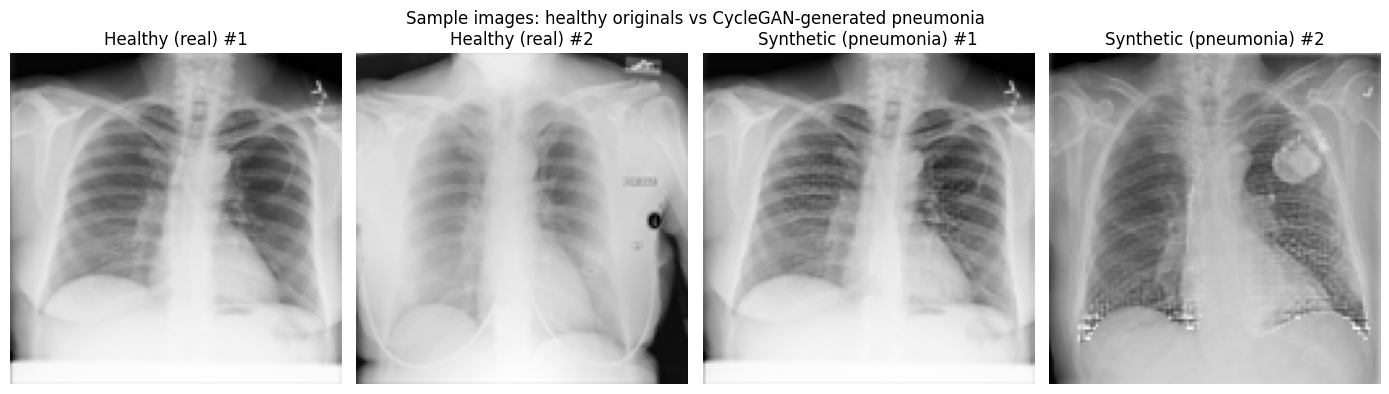

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# Two healthy originals
for i in range(2):
    img = train_dataset.images[i].convert("L")
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Healthy (real) #{i+1}")
    axes[i].axis("off")

# Two CycleGAN synthetics
for i in range(2):
    img = Image.open(gen_img_paths[i]).convert("L")
    axes[2 + i].imshow(img, cmap="gray")
    axes[2 + i].set_title(f"Synthetic (pneumonia) #{i+1}")
    axes[2 + i].axis("off")

fig.suptitle("Sample images: healthy originals vs CycleGAN-generated pneumonia", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "sample_images.png", dpi=150)
plt.show()

## 6. DataLoaders & Class Weighting

In [9]:
n_neg = n_base_neg
n_pos = n_base_pos + len(synthetic_train)

prop_pos = n_pos / (n_pos + n_neg)
print(f"Combined — Healthy: {n_neg} | Pneumonia (real + synthetic): {n_pos}")
print(f"Proportion positive: {prop_pos*100:.2f}%")

# Same attenuated formula as notebook 1.2 for comparability
x_desired  = 0.1
pos_weight = (x_desired * (n_neg / n_pos)) / 0.5
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)
print(f"Raw ratio:             {n_neg/n_pos:.4f}")
print(f"Attenuated pos_weight: {pos_weight.item():.4f}")

Combined — Healthy: 42436 | Pneumonia (real + synthetic): 6455
Proportion positive: 13.20%
Raw ratio:             6.5741
Attenuated pos_weight: 1.3148


In [10]:
train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 7. Model, Loss, Optimizer

In [11]:
torch.manual_seed(SEED)

model     = SimpleCNN(dropout_rate=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=cfg.training.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
     

## 8. Training

In [12]:
best_val_auc, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    device=DEVICE,
)

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

Epoch 01/10 | elapsed_time=490.64s| train_loss=0.1400 | train_auc=0.9677 | val_loss=0.3090 | val_auc=0.5448 ← best 
Epoch 02/10 | elapsed_time=465.95s| train_loss=0.0607 | train_auc=0.9845 | val_loss=0.0479 | val_auc=0.6246 ← best 
Epoch 03/10 | elapsed_time=466.15s| train_loss=0.0519 | train_auc=0.9868 | val_loss=0.0491 | val_auc=0.6204 
Epoch 04/10 | elapsed_time=467.17s| train_loss=0.0523 | train_auc=0.9856 | val_loss=0.0468 | val_auc=0.6174 
Epoch 05/10 | elapsed_time=463.07s| train_loss=0.0489 | train_auc=0.9859 | val_loss=0.0491 | val_auc=0.6159 
Epoch 06/10 | elapsed_time=464.53s| train_loss=0.0470 | train_auc=0.9856 | val_loss=0.0468 | val_auc=0.6491 ← best 
Epoch 07/10 | elapsed_time=463.35s| train_loss=0.0445 | train_auc=0.9860 | val_loss=13.7991 | val_auc=0.5462 
Epoch 08/10 | elapsed_time=464.23s| train_loss=0.0454 | train_auc=0.9859 | val_loss=0.0465 | val_auc=0.6324 
Epoch 09/10 | elapsed_time=463.12s| train_loss=0.0441 | train_auc=0.9860 | val_loss=0.0498 | val_auc=0.603

## 9. Training Curves

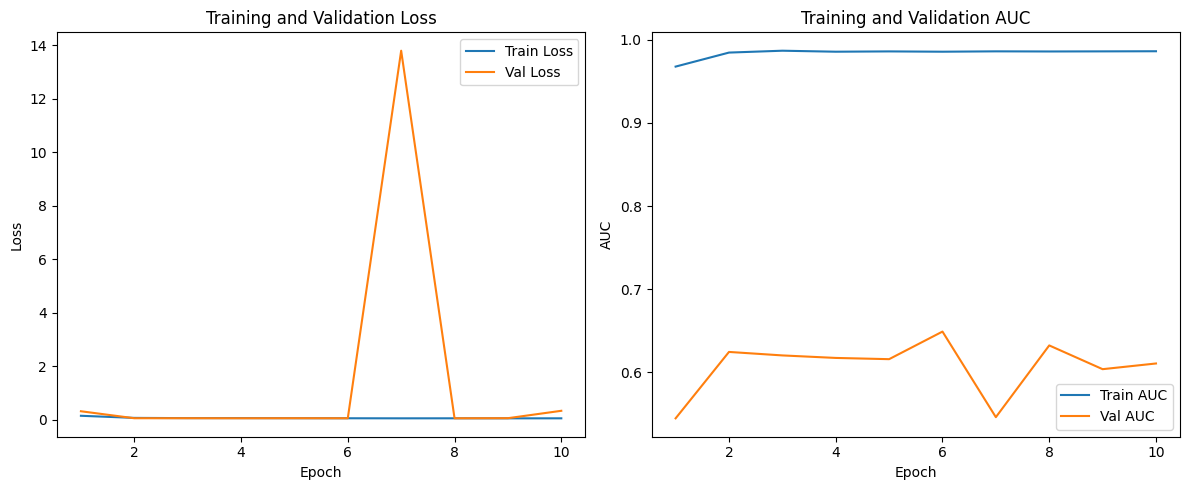

<Figure size 640x480 with 0 Axes>

In [13]:
training_curves(history, results_path=RESULTS_DIR / "training_curves.png")

## 10. Evaluation on Test Set

In [14]:
from sklearn.metrics import roc_curve

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

_, val_y, val_sc   = run_epoch(val_loader,  model.to(DEVICE), criterion, device=DEVICE)
_, test_y, test_sc = run_epoch(test_loader, model.to(DEVICE), criterion, device=DEVICE)

fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_threshold       = thresholds[np.argmax(tpr - fpr)]

print("=== Test Set Metrics ===")
print_metrics(test_y, test_sc, threshold=best_threshold)

=== Test Set Metrics ===
Accuracy : 0.5047
AUC-ROC  : 0.6257
Confusion matrix (threshold=0.008210974745452404):
  TN=4523  FP=4455
  FN=13  TP=30


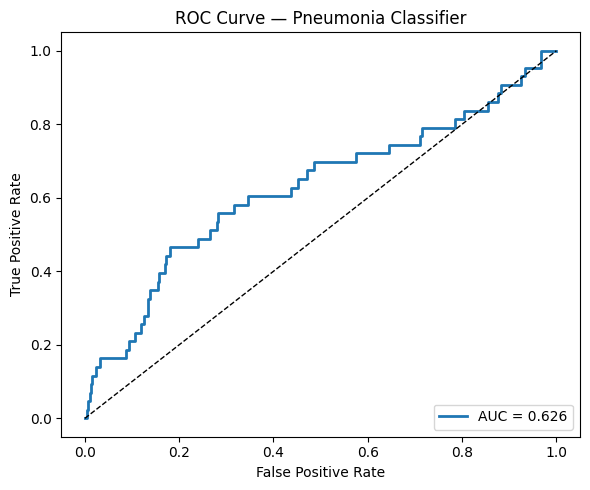

In [15]:
fig = plot_roc_curve(test_y, test_sc, save_path=RESULTS_DIR / "roc_curve.png")
plt.show()

## 11. Save Results

In [16]:
from metrics import compute_accuracy, compute_roc_auc

save_results(
    model        = cfg.model.name,
    img_size     = list(cfg.data.img_size),
    epochs       = NUM_EPOCHS,
    batch_size   = BATCH_SIZE,
    lr           = LR,
    dropout      = DROPOUT,
    seed         = SEED,
    pos_weight   = pos_weight,
    augmentation = {
        "strategy":                      "cyclegan_synthetic_flipped",
        "cyclegan_flipped_samples":      len(synthetic_train),
        "real_pneumonia_samples":        n_base_pos,
        "healthy_samples":               n_base_neg,
        "total_train_samples":           len(combined_train),
        "flip_scores_csv":               str(FLIP_CSV),
    },
    best_val_auc  = best_val_auc,
    test_accuracy = compute_accuracy(test_y, test_sc, threshold=best_threshold),
    test_auc_roc  = compute_roc_auc(test_y, test_sc),
    history       = history,
    results_path  = RESULTS_DIR / f"{cfg.model.name}_results.json",
)

Results saved to C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\cyclegan_augmented_cnn_20260615-232507\SimpleCNN_cyclegan_aug_results.json
{
  "model": "SimpleCNN_cyclegan_aug",
  "img_size": [
    224,
    224
  ],
  "epochs": 10,
  "batch_size": 64,
  "lr": 0.0003,
  "dropout": 0.3,
  "seed": 42,
  "pos_weight": 1.3148,
  "augmentation": {
    "strategy": "cyclegan_synthetic_flipped",
    "cyclegan_flipped_samples": 6230,
    "real_pneumonia_samples": 225,
    "healthy_samples": 42436,
    "total_train_samples": 48891,
    "flip_scores_csv": "C:\\Users\\User\\Documents\\0Unicamp\\IA376N\\Projeto\\dgm-2026.1\\projects\\ecgpcx-ray\\results\\cyclegan_h2p_train_scores.csv"
  },
  "best_val_auc": 0.6491,
  "test_accuracy": 0.5047,
  "test_auc_roc": 0.6257
}
